# WWFS Birchgletscher

In [1]:
using Pkg; Pkg.activate("/scratch-3/cogier/hydraulic_barriers/")
Pkg.resolve()
using Rasters
#using Shapefile
using WhereTheWaterFlowsSubglacially, WhereTheWaterFlows
const WWFS = WhereTheWaterFlowsSubglacially
const WWF = WhereTheWaterFlows
using ArchGDAL
#using MAT
using Plots
#using GlacioTools
include("/scratch-3/cogier/GlacioTools.jl/src/Rasters_helpers.jl")
#using GLMakie
#Pkg.status()
#include("/scratch-3/cogier/WhereTheWaterFlowsSubglacially.jl/src/helpers.jl")
using CSV
using DataFrames
#import GeoStats  #GeoStats.area conflicts with the WWFS outout area
using Images
using ImageComponentAnalysis
using Statistics
include("/scratch-3/cogier/hydraulic_barriers/notebooks/functions.jl")

  Activating project at `/scratch-3/cogier/hydraulic_barriers`
  No Changes to `/scratch-3/cogier/hydraulic_barriers/Project.toml`
  No Changes to `/scratch-3/cogier/hydraulic_barriers/Manifest.toml`


boxplot_lakes

In [12]:
# functions
include("/scratch-3/cogier/hydraulic_barriers/notebooks/functions.jl")
datadir_in = "/scratch-3/cogier/data/Birch_input/"
datadir_out = "/scratch-3/cogier/data/Birch_output/"

"/scratch-3/cogier/data/Birch_output/"

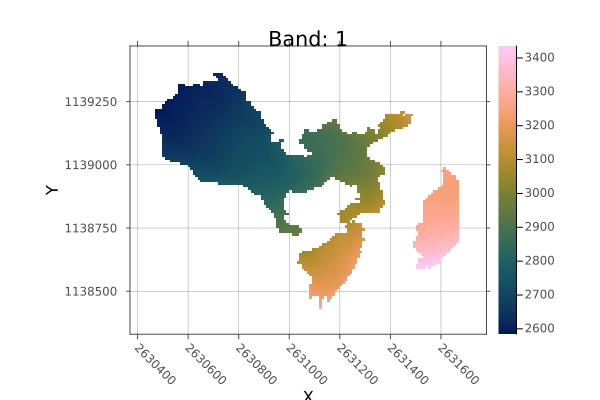

In [16]:
bed = Raster(joinpath(datadir_in,"B32-06_GlacierBed.tif"));
heatmap(bed)

In [17]:
#20230823
surf_23 = Raster(joinpath(datadir_in,"B32-06_birch_20230823_dsm_is-stand_2m_lv95_ln02.tif"));
#20250523 5 days before the detachment
surf_25 = Raster(joinpath(datadir_in,"dronecam-2025-05-23T10_28_00-dem_200mmPP.tif"));

In [ ]:
# do simple WWF (just over bedrock)
bed = resample(bed; to = surf_23,method=:bilinear)

## get cell size for WWFS
x,y = dims(surf_23)
dx = step(dims(surf_23)[1])

(area, slen, dir, nout, nin, pits, c, bnds),
         (sc_locs, kappas, diro, phi),
         (lakes, lakes_free_surf),
         sinkout = WWFS.waterflows_subglacial(surf_23, bed, dx, gamma=[0,WWFS.GAMMA][1], bnd_as_sink=true, drain_pits=true);

TypeError: TypeError: non-boolean (Missing) used in boolean context